In [1]:
import numpy as np
import matplotlib.pyplot as plt



# ============================================
# Safari-Safe-AI | Phase 3
# F=ma to Self-Attention Bridge
# Author: Ben Ogega | BRIDGE Framework
# ============================================

# Your driving sequence — 10 timesteps
# Nairobi — Mombasa Road — dangerous event at t=7


In [2]:


speeds_kmh = np.array([
    88.0,   # t=0 normal highway
    89.0,   # t=1 slight acceleration
    91.0,   # t=2 still accelerating
    92.0,   # t=3 cruising
    91.5,   # t=4 slight variation
    92.0,   # t=5 normal
    93.0,   # t=6 still normal
    60.0,   # t=7 HARSH BRAKING — dangerous event
    45.0,   # t=8 still braking
    44.0,   # t=9 nearly stopped
])

# Convert to m/s — Newton's laws work in SI units
speeds_ms = speeds_kmh / 3.6

print("Speeds (m/s):", speeds_ms)

Speeds (m/s): [24.44444444 24.72222222 25.27777778 25.55555556 25.41666667 25.55555556
 25.83333333 16.66666667 12.5        12.22222222]


In [3]:
# Simple moving average to filter sensor jitter
window_size = 3
smoothed_speeds = np.convolve(speeds_ms, np.ones(window_size)/window_size, mode='valid')
print("Smoothed Speeds (m/s):", smoothed_speeds)

Smoothed Speeds (m/s): [24.81481481 25.18518519 25.41666667 25.50925926 25.60185185 22.68518519
 18.33333333 13.7962963 ]


In [4]:
dt = 1.0  # 1 second between readings
accelerations = np.diff(speeds_ms) / dt

In [5]:
print("="*55)
print("STEP 1 — F=ma: Acceleration at each timestep")
print("="*55)
for i, a in enumerate(accelerations):
    flag = " ← DANGEROUS" if abs(a) > 3.5 else ""
    print(f"  t={i}→{i+1}: {a:+.3f} m/s²{flag}")

print(f"\nMost dangerous moment: t={np.argmin(accelerations)}→{np.argmin(accelerations)+1}")
print(f"Peak deceleration: {accelerations.min():.3f} m/s²")

STEP 1 — F=ma: Acceleration at each timestep
  t=0→1: +0.278 m/s²
  t=1→2: +0.556 m/s²
  t=2→3: +0.278 m/s²
  t=3→4: -0.139 m/s²
  t=4→5: +0.139 m/s²
  t=5→6: +0.278 m/s²
  t=6→7: -9.167 m/s² ← DANGEROUS
  t=7→8: -4.167 m/s² ← DANGEROUS
  t=8→9: -0.278 m/s²

Most dangerous moment: t=6→7
Peak deceleration: -9.167 m/s²


In [6]:
# Or Create a boolean mask of dangerous events
dangerous_indices = np.where(np.abs(accelerations) > 3.5)[0]
print(f"Dangerous Timesteps detected at: {dangerous_indices}")

Dangerous Timesteps detected at: [6 7]


In [7]:
# Adding a simple subplot  showing the Speed profile vs. the Acceleration profile will make the "Dangerous" event at t=7 visually undeniable.

Calculated Accelerations (m/s^2): [ 0.27777778  0.55555556  0.27777778 -0.13888889  0.13888889  0.27777778
 -9.16666667 -4.16666667 -0.27777778]


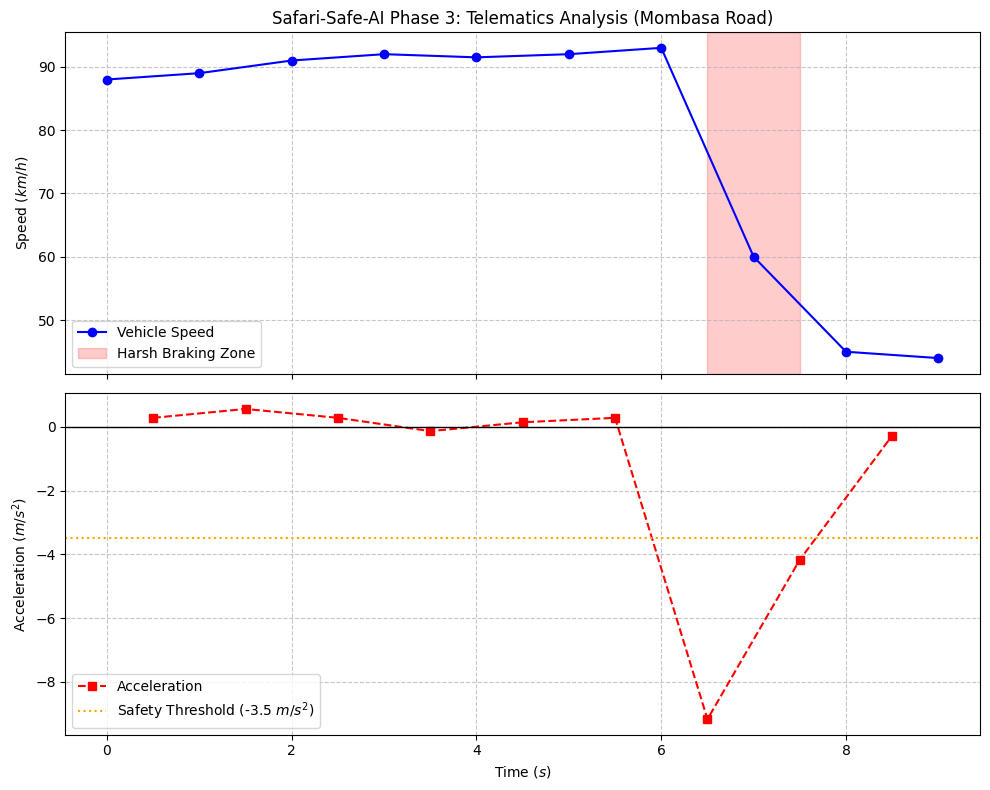

In [8]:
# Data from user
timestamps = np.arange(0, 10, 1.0)
speeds_kmh = np.array([88.0, 89.0, 91.0, 92.0, 91.5, 92.0, 93.0, 60.0, 45.0, 44.0])
speeds_ms = speeds_kmh / 3.6
dt = 1.0
accelerations = np.diff(speeds_ms) / dt

# Time midpoints for acceleration plot
accel_times = timestamps[:-1] + 0.5

# Create plots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Plot 1: Speed
ax1.plot(timestamps, speeds_kmh, marker='o', color='b', linestyle='-', label='Vehicle Speed')
ax1.axvspan(6.5, 7.5, color='red', alpha=0.2, label='Harsh Braking Zone')
ax1.set_ylabel('Speed ($km/h$)')
ax1.set_title('Safari-Safe-AI Phase 3: Telematics Analysis (Mombasa Road)')
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend()

# Plot 2: Acceleration
ax2.plot(accel_times, accelerations, marker='s', color='r', linestyle='--', label='Acceleration')
ax2.axhline(0, color='black', linewidth=1)
ax2.axhline(-3.5, color='orange', linestyle=':', label='Safety Threshold (-3.5 $m/s^2$)')
ax2.set_ylabel('Acceleration ($m/s^2$)')
ax2.set_xlabel('Time ($s$)')
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend()

plt.tight_layout()
plt.savefig('../figures/safari_safe_telematics.png')

print("Calculated Accelerations (m/s^2):", accelerations)

In [9]:
# Parameters
g = 9.81              # m/s^2
mu_asphalt = 0.7      # Dry asphalt (standard)
mu_gravel = 0.35      # Loose surface/Wet (dangerous)
reaction_time = 1.5   # Nairobi traffic "distracted" estimate (seconds)

# 1. Calculate Maximum Braking Capacity
max_a_asphalt = -mu_asphalt * g
max_a_gravel = -mu_gravel * g

# 2. Identify Skidding Events
skidding_on_asphalt = accelerations < max_a_asphalt
skidding_on_gravel = accelerations < max_a_gravel

# 3. Calculate "Perception-Reaction Distance"
# Distance traveled before the driver even hits the brakes
reaction_distance = speeds_ms[6] * reaction_time 

print(f"Max Deceleration (Asphalt): {max_a_asphalt:.2f} m/s²")
print(f"Max Deceleration (Gravel):  {max_a_gravel:.2f} m/s²")
print("-" * 40)

# Check our t=6->7 event (-9.17 m/s²)
if accelerations[6] < max_a_asphalt:
    print(f"CRITICAL: At t=7, vehicle is SKIDDING even on dry asphalt!")

print(f"Distance covered during reaction time: {reaction_distance:.2f} meters")

Max Deceleration (Asphalt): -6.87 m/s²
Max Deceleration (Gravel):  -3.43 m/s²
----------------------------------------
CRITICAL: At t=7, vehicle is SKIDDING even on dry asphalt!
Distance covered during reaction time: 38.75 meters


In [10]:
# Lead vehicle speed (constant 70 km/h)
lead_speed_ms = 70 / 3.6 

# Initial gap at t=0 (meters)
initial_gap = 50 

# 1. Calculate Relative Speed at each timestep
# If positive, you are gaining on the lead vehicle
rel_speeds = speeds_ms - lead_speed_ms

# 2. Track the Gap over time (Numerical Integration)
# gap_t = gap_{t-1} - (rel_speed * dt)
gaps = [initial_gap]
for rs in rel_speeds:
    new_gap = gaps[-1] - (rs * dt)
    gaps.append(max(0, new_gap)) # Gap can't be less than 0 (collision)

gaps = np.array(gaps[:-1]) # Align with timestamps

# 3. Time-to-Collision (TTC) 
# TTC = Gap / Relative Speed (only when closing the gap)
ttc = np.where(rel_speeds > 0, gaps / rel_speeds, np.inf)

print("="*55)
print("PHASE 3 REFINEMENT: Collision Awareness")
print("="*55)
for i, t in enumerate(ttc):
    status = "⚠️ WARNING" if t < 3.0 else "Safe"
    print(f"t={i}: Gap={gaps[i]:.1f}m | TTC={t:.2f}s | {status}")

PHASE 3 REFINEMENT: Collision Awareness
t=0: Gap=50.0m | TTC=10.00s | Safe
t=1: Gap=45.0m | TTC=8.53s | Safe
t=2: Gap=39.7m | TTC=6.81s | Safe
t=3: Gap=33.9m | TTC=5.55s | Safe
t=4: Gap=27.8m | TTC=4.65s | Safe
t=5: Gap=21.8m | TTC=3.57s | Safe
t=6: Gap=15.7m | TTC=2.46s | ⚠️ WARNING
t=7: Gap=9.3m | TTC=infs | Safe
t=8: Gap=12.1m | TTC=infs | Safe
t=9: Gap=19.0m | TTC=infs | Safe


STEP 2 — F=ma to Self-Attention Bridge
Timestep     |Accel| m/s²     Attention Weight   Bar
-------------------------------------------------------
  t=0        0.278            0.0001             
  t=1        0.556            0.0002             
  t=2        0.278            0.0001             
  t=3        0.139            0.0001             
  t=4        0.139            0.0001             
  t=5        0.278            0.0001             
  t=6        9.167            0.9923             ███████████████████████████████████████████████████████████████████████████████████████████████████ <- MODEL FOCUSED
  t=7        4.167            0.0067             
  t=8        0.278            0.0001             

Sum of weights: 1.0000
Most attended:  t=6
Peak weight:    0.9923


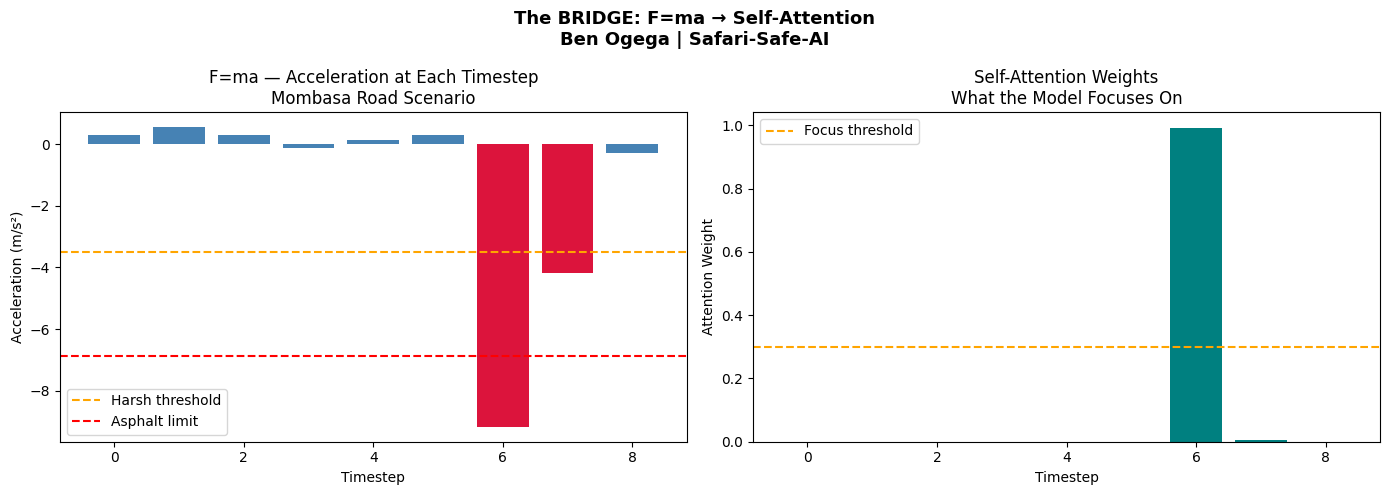

Bridge visualization saved.


In [11]:
# ============================================
# STEP 2 — SELF-ATTENTION SCORES
# The F=ma to Self-Attention Bridge
# Author: Ben Ogega | BRIDGE Framework
# ============================================

accels = np.array([0.278, 0.556, 0.278, -0.139,
                   0.139, 0.278, -9.167, -4.167, -0.278])

# ============================================
# THE BRIDGE — explained once, understood forever
#
# F = ma tells us: larger acceleration = larger force
# The dangerous timestep has the largest |acceleration|
#
# Self-Attention tells us: which timestep matters most?
# Answer: the one with the highest relevance score
#
# Both systems assign WEIGHTS to timesteps.
# F=ma weights by physical magnitude.
# Attention weights by learned relevance.
# Same philosophy. Different mathematics.
# ============================================

# Raw importance — absolute acceleration magnitude
raw_scores = np.abs(accels)

# Softmax — normalize to probability distribution
# Like distributing a unit load across support reactions
def softmax(x):
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum()

attention_weights = softmax(raw_scores)

print("STEP 2 — F=ma to Self-Attention Bridge")
print("="*55)
print(f"{'Timestep':<12} {'|Accel| m/s²':<16} {'Attention Weight':<18} {'Bar'}")
print("-"*55)
for i, (s, w) in enumerate(zip(raw_scores, attention_weights)):
    bar = '█' * int(w * 100)
    focus = " <- MODEL FOCUSED" if w > 0.3 else ""
    print(f"  t={i:<8} {s:<16.3f} {w:<18.4f} {bar}{focus}")

print(f"\nSum of weights: {attention_weights.sum():.4f}")
print(f"Most attended:  t={np.argmax(attention_weights)}")
print(f"Peak weight:    {attention_weights.max():.4f}")

# ============================================
# STEP 3 — VISUALIZE THE BRIDGE
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — F=ma: Raw accelerations
colors = ['crimson' if abs(a) > 3.5 else 'steelblue' for a in accels]
axes[0].bar(range(len(accels)), accels, color=colors)
axes[0].axhline(y=-3.5, color='orange', linestyle='--', label='Harsh threshold')
axes[0].axhline(y=-6.87, color='red', linestyle='--', label='Asphalt limit')
axes[0].set_title('F=ma — Acceleration at Each Timestep\nMombasa Road Scenario')
axes[0].set_xlabel('Timestep')
axes[0].set_ylabel('Acceleration (m/s²)')
axes[0].legend()

# Plot 2 — Self-Attention weights
axes[1].bar(range(len(attention_weights)),
            attention_weights, color='teal')
axes[1].set_title('Self-Attention Weights\nWhat the Model Focuses On')
axes[1].set_xlabel('Timestep')
axes[1].set_ylabel('Attention Weight')
axes[1].axhline(y=0.3, color='orange', linestyle='--', label='Focus threshold')
axes[1].legend()

plt.suptitle('The BRIDGE: F=ma → Self-Attention\nBen Ogega | Safari-Safe-AI',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/phase3_bridge_fma_attention.png')
plt.show()
print("Bridge visualization saved.")